In [3]:
%pip install pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [5]:
!pip install openpyxl

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Successful!")

Setup Successful!


# Customer Churn Exploratory Data Analysis

### Student Name: Sasi Rekha

### Dataset:
E Commerce Dataset

### Objective

The objective of this project is to analyze customer churn behavior using exploratory data analysis (EDA). The project identifies important factors affecting customer churn and provides business recommendations to improve customer retention.

In [7]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

# Plot style
plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
import pandas as pd

file_path = r"C:\Users\ELCOT\Desktop\Customer_Churn_EDA_SasiRekha\data\E Commerce Dataset.xlsx"
df = pd.read_excel(file_path, sheet_name="E Comm")
print("Dataset Loaded Successfully!")


Dataset Loaded Successfully!


In [9]:
#Display the First Five Rows

df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [10]:
#Display the Last Five Rows

df.tail()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90
5629,55630,0,8.0,Mobile Phone,1,15.0,Credit Card,Male,3.0,2,Laptop & Accessory,3,Married,4,0,13.0,2.0,2.0,3.0,169.04


In [11]:
#Check Dataset Shape

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 5630
Columns : 20


In [12]:
#Column Names 

df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

In [13]:
#Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [14]:
#Statistical Summary

df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [15]:
#statistical Summary (Including Categorical Columns)

df.describe(include="all")

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630,5630.000000,5379.000000,5630,5630,5375.000000,5630.000000,5630,5630.000000,5630,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
unique,NaN,NaN,NaN,3,NaN,NaN,7,2,NaN,NaN,6,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Mobile Phone,NaN,NaN,Debit Card,Male,NaN,NaN,Laptop & Accessory,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2765,NaN,NaN,2314,3384,NaN,NaN,2050,NaN,2986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,52815.500000,0.168384,10.189899,NaN,1.654707,15.639896,NaN,NaN,2.931535,3.688988,NaN,3.066785,NaN,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,NaN,0.915389,8.531475,NaN,NaN,0.721926,1.023999,NaN,1.380194,NaN,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,NaN,1.000000,5.000000,NaN,NaN,0.000000,1.000000,NaN,1.000000,NaN,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,NaN,1.000000,9.000000,NaN,NaN,2.000000,3.000000,NaN,2.000000,NaN,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,NaN,1.000000,14.000000,NaN,NaN,3.000000,4.000000,NaN,3.000000,NaN,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,NaN,3.000000,20.000000,NaN,NaN,3.000000,4.000000,NaN,4.000000,NaN,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500


In [16]:
#Check Data Types

df.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

In [17]:
#count Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print("Number of Numerical Columns :", len(numerical_columns))
print("Number of Categorical Columns :", len(categorical_columns))

Number of Numerical Columns : 15
Number of Categorical Columns : 5


In [18]:
print("Numerical Columns:\n")
print(numerical_columns)

print("\nCategorical Columns:\n")
print(categorical_columns)

Numerical Columns:

Index(['CustomerID', 'Churn', 'Tenure', 'CityTier', 'WarehouseToHome',
       'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore',
       'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear',
       'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

Categorical Columns:

Index(['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender',
       'PreferedOrderCat', 'MaritalStatus'],
      dtype='object')


In [19]:
#Check the Target Variable (Churn)

df["Churn"].value_counts()

Churn
0    4682
1     948
Name: count, dtype: int64

In [20]:
#display percentages:

(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
0    83.16
1    16.84
Name: proportion, dtype: float64

In [21]:
#Check Unique Values

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']

PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender
['Female' 'Male']

PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus
['Single' 'Divorced' 'Married']


In [22]:
#Check Missing Values

df.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [23]:
#display them in descending order:

missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values

DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
CustomerID                       0
PreferredLoginDevice             0
Churn                            0
PreferredPaymentMode             0
CityTier                         0
SatisfactionScore                0
PreferedOrderCat                 0
NumberOfDeviceRegistered         0
Gender                           0
Complain                         0
NumberOfAddress                  0
MaritalStatus                    0
CashbackAmount                   0
dtype: int64

In [24]:
#Missing Value Percentage

missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_percentage.sort_values(ascending=False)

DaySinceLastOrder              5.45
OrderAmountHikeFromlastYear    4.71
Tenure                         4.69
OrderCount                     4.58
CouponUsed                     4.55
HourSpendOnApp                 4.53
WarehouseToHome                4.46
CustomerID                     0.00
PreferredLoginDevice           0.00
Churn                          0.00
PreferredPaymentMode           0.00
CityTier                       0.00
SatisfactionScore              0.00
PreferedOrderCat               0.00
NumberOfDeviceRegistered       0.00
Gender                         0.00
Complain                       0.00
NumberOfAddress                0.00
MaritalStatus                  0.00
CashbackAmount                 0.00
dtype: float64

In [25]:
#Check Duplicate Rows

df.duplicated().sum()

np.int64(0)

## Dataset Summary

- Total number of rows:
- Total number of columns:
- Target column: Churn
- Numerical features:
- Categorical features:
- Missing values:
- Duplicate records:

The dataset contains customer demographic details, shopping behavior, and satisfaction-related features. The objective is to identify the factors influencing customer churn.

In [26]:
#Create a Copy of the Dataset

# Create a copy of the original dataset
df_clean = df.copy()

In [27]:
#Check Missing Values

# Missing values in each column
df_clean.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [28]:
#Display only columns with missing values:

missing = df_clean.isnull().sum()
missing[missing > 0]

Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

### Observation

The dataset contains missing values in a few numerical columns such as
WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear,
CouponUsed, OrderCount and DaySinceLastOrder.

These missing values will be handled using the median value because
median is less affected by outliers.

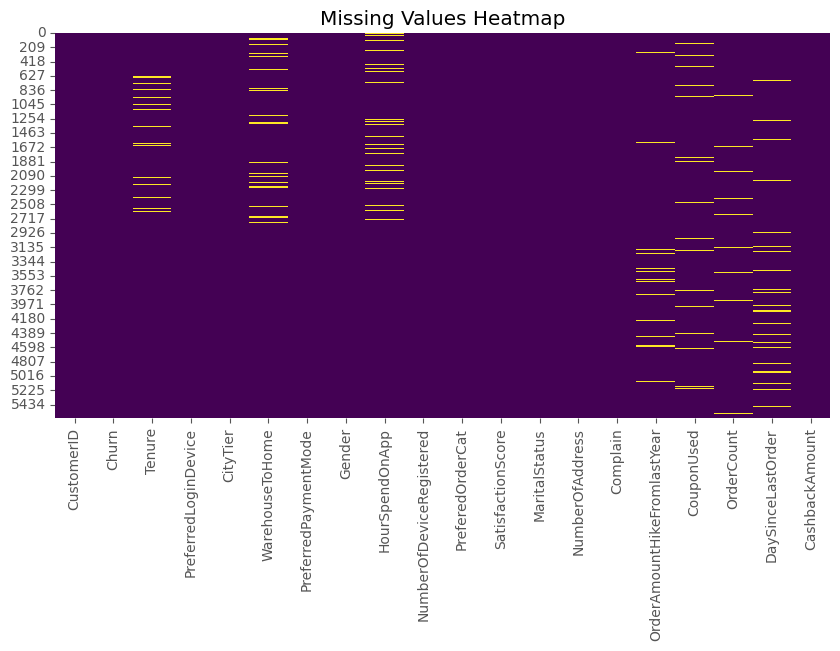

In [29]:
#Visualize Missing Values

plt.figure(figsize=(10,5))

sns.heatmap(df_clean.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

The heatmap clearly shows that only a few columns contain missing values.
Most columns are complete.

In [30]:
#Fill Missing Numerical Values

numerical_columns = df_clean.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_3016\2813029352.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\ELCOT\AppData\Local\Temp\ipykernel_3016\2813029352.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [31]:
df_clean.isnull().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

All missing numerical values have been replaced with the median values.
No missing values remain in numerical columns.

In [32]:
#Check Duplicate Records

df_clean.duplicated().sum()

np.int64(0)

In [33]:
#Remove Duplicate Records (If Any)

df_clean = df_clean.drop_duplicates()

In [34]:
df_clean.duplicated().sum()

np.int64(0)

Duplicate records have been removed successfully.

In [35]:
#Check Data Types

df_clean.dtypes

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

Most columns already have appropriate data types.
No major data type conversion is required.

In [36]:
#Check Unique Values in Categorical Columns

categorical_columns = df_clean.select_dtypes(include="object").columns

for col in categorical_columns:
    print("="*50)
    print(col)
    print(df_clean[col].unique())

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']
PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
Gender
['Female' 'Male']
PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
MaritalStatus
['Single' 'Divorced' 'Married']


In [37]:
#Remove Extra Spaces

for col in categorical_columns:
    df_clean[col] = df_clean[col].str.strip()

In [38]:
for col in categorical_columns:
    print(col)
    print(df_clean[col].unique())

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']
PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']
Gender
['Female' 'Male']
PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']
MaritalStatus
['Single' 'Divorced' 'Married']


Leading and trailing spaces have been removed from categorical columns,
ensuring consistent values.

In [39]:
#Remove Unnecessary Columns

df_clean.drop("CustomerID", axis=1, inplace=True)

In [40]:
df_clean.head()

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


The CustomerID column has been removed because it does not contribute
to churn analysis.

In [41]:
#Check Dataset Shape After Cleaning

print("Rows :", df_clean.shape[0])
print("Columns :", df_clean.shape[1])

Rows : 5630
Columns : 19


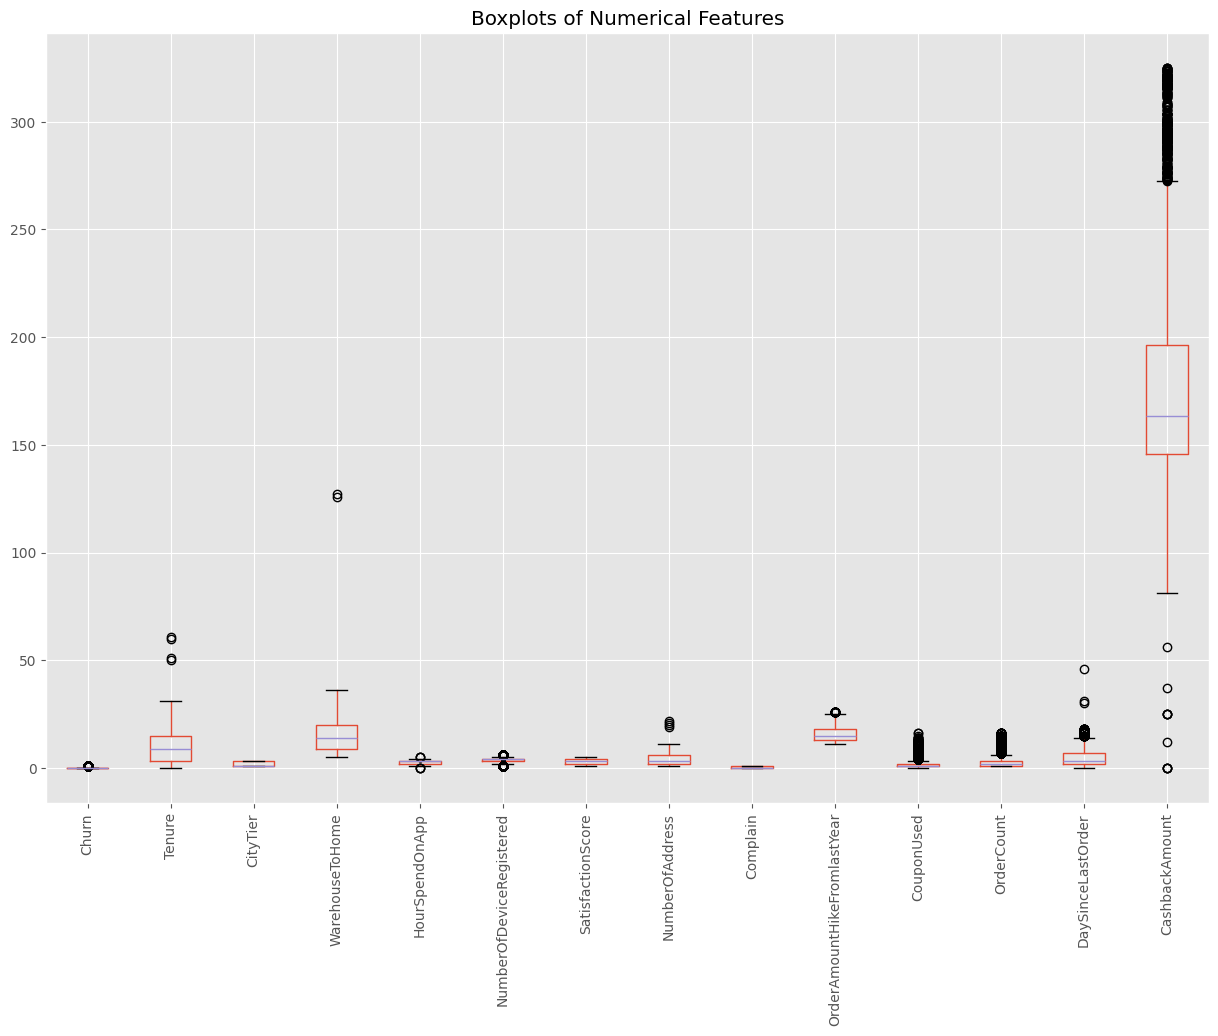

In [43]:
#Detect Outliers Using Boxplots

plt.figure(figsize=(15,10))

df_clean.boxplot(rot=90)

plt.title("Boxplots of Numerical Features")
plt.show()

Several numerical columns contain outliers.
These are expected in customer transaction data and will be retained
because they may represent genuine customer behavior.

In [45]:
#Detect Outliers Using IQR

numerical_columns = df_clean.select_dtypes(include=np.number).columns

outlier_summary = {}

for col in numerical_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]

    outlier_summary[col] = len(outliers)

outlier_summary

{'Churn': 948,
 'Tenure': 4,
 'CityTier': 0,
 'WarehouseToHome': 2,
 'HourSpendOnApp': 6,
 'NumberOfDeviceRegistered': 397,
 'SatisfactionScore': 0,
 'NumberOfAddress': 4,
 'Complain': 0,
 'OrderAmountHikeFromlastYear': 33,
 'CouponUsed': 629,
 'OrderCount': 703,
 'DaySinceLastOrder': 62,
 'CashbackAmount': 438}

In [46]:
#Display Outlier Counts

outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Column", "Number of Outliers"]
)

outlier_df

,Column,Number of Outliers
0,Churn,948
1,Tenure,4
2,CityTier,0
3,WarehouseToHome,2
4,HourSpendOnApp,6
5,NumberOfDeviceRegistered,397
6,SatisfactionScore,0
7,NumberOfAddress,4
8,Complain,0
9,OrderAmountHikeFromlastYear,33


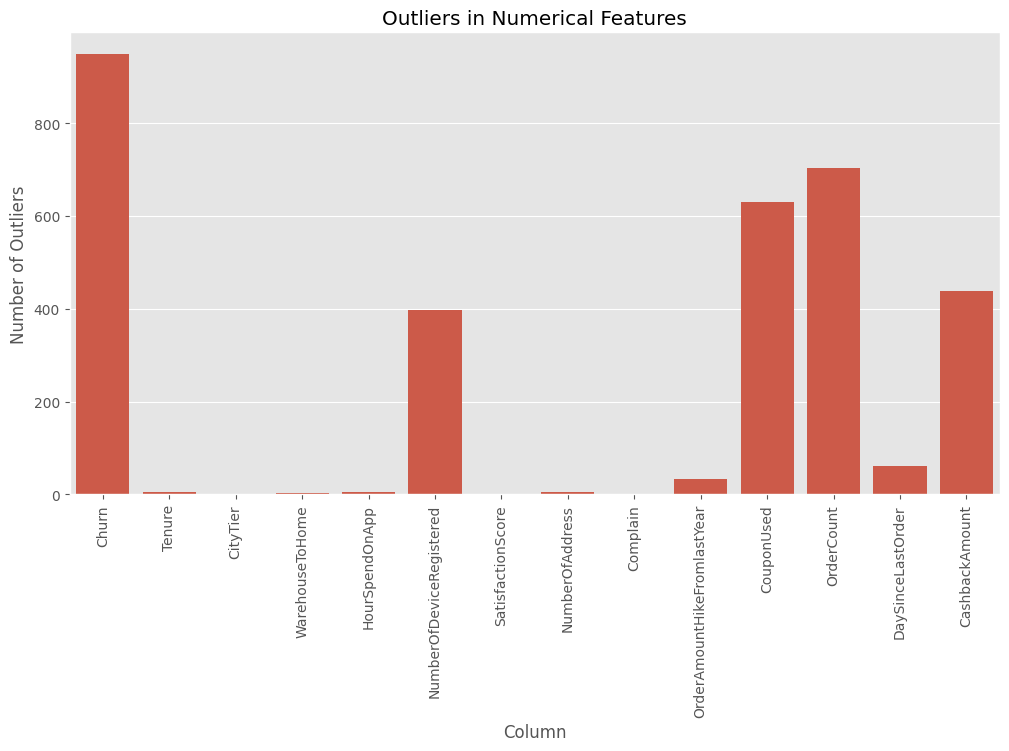

In [47]:
#Plot Outlier Counts

plt.figure(figsize=(12,6))

sns.barplot(
    data=outlier_df,
    x="Column",
    y="Number of Outliers"
)

plt.xticks(rotation=90)

plt.title("Outliers in Numerical Features")

plt.show()

Some numerical features contain outliers.
These values are retained because they may represent valuable business
information rather than errors.

In [48]:
#Final Missing Value Check

df_clean.isnull().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [49]:
#Saving the Cleaned Dataset

import os

# Define the directory and file path
output_dir = "../cleaned_data"
file_path = os.path.join(output_dir, "Cleaned_Customer_Churn_Dataset_SasiRekha.csv")

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Saving the Cleaned Dataset
df_clean.to_csv(file_path, index=False)
print("Cleaned dataset saved successfully!")


Cleaned dataset saved successfully!


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_3016\1041894726.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0.5, 1.0, 'Customer Churn Count')

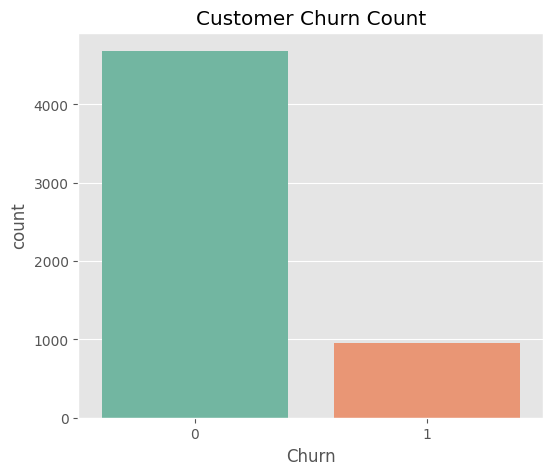

In [50]:
#Univariate Analysis
#Churn Count Plot

# Import the required libraries first
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis
# Churn Count Plot
plt.figure(figsize=(6,5))

sns.countplot(
    x="Churn",
    data=df_clean,
    palette="Set2"
)

plt.title("Customer Churn Count")


### Observation

- The chart shows the number of customers who churned and those who stayed.
- Most customers did not churn.
- This indicates customer retention is higher than customer attrition.

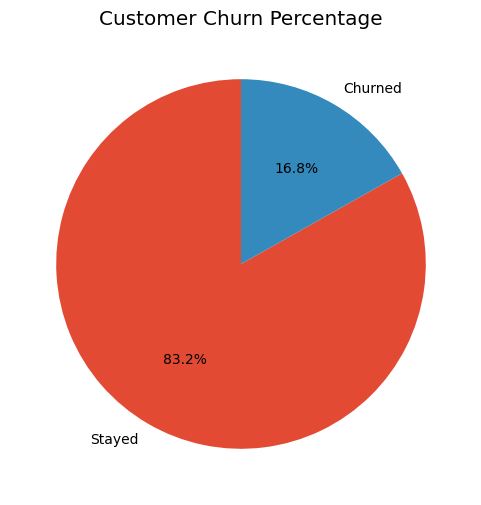

In [51]:
#Churn Percentage Pie Chart

churn_counts = df_clean["Churn"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=["Stayed","Churned"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

### Observation

Approximately one-fifth of customers have churned while the remaining customers are retained.

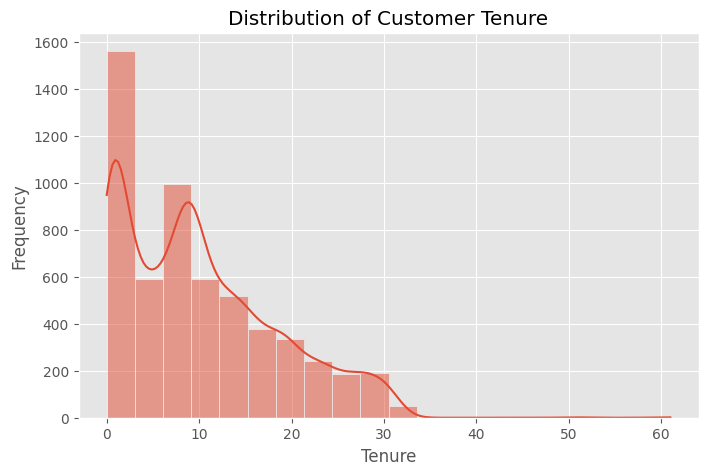

In [52]:
#Tenure Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["Tenure"],
    bins=20,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.show()

### Observation

Most customers have relatively short to medium tenure, while fewer customers remain for very long periods.

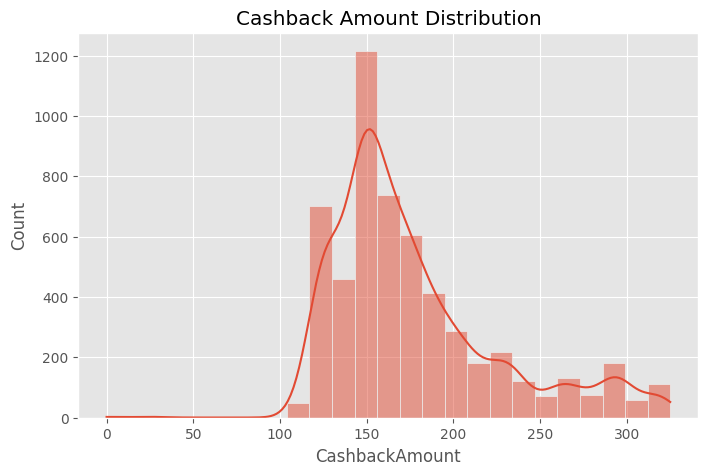

In [53]:
#Cashback Amount Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df_clean["CashbackAmount"],
    bins=25,
    kde=True
)

plt.title("Cashback Amount Distribution")

plt.show()

### Observation

Cashback amounts are concentrated around the average values, with a few customers receiving higher cashback.

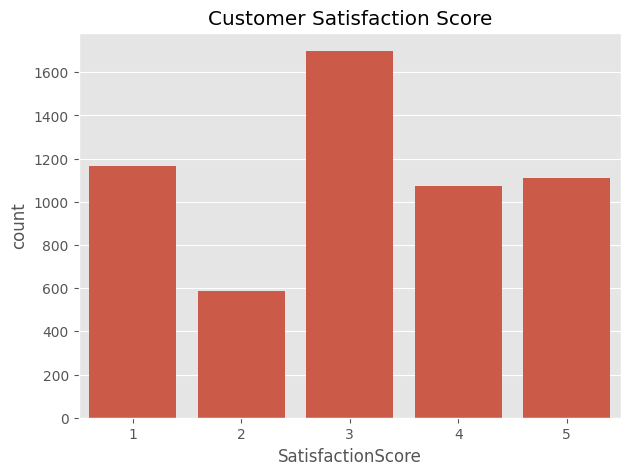

In [54]:
#Satisfaction Score Distribution

plt.figure(figsize=(7,5))

sns.countplot(
    x="SatisfactionScore",
    data=df_clean
)

plt.title("Customer Satisfaction Score")

plt.show()

### Observation

Customer satisfaction scores are distributed across all rating levels, indicating varying customer experiences.

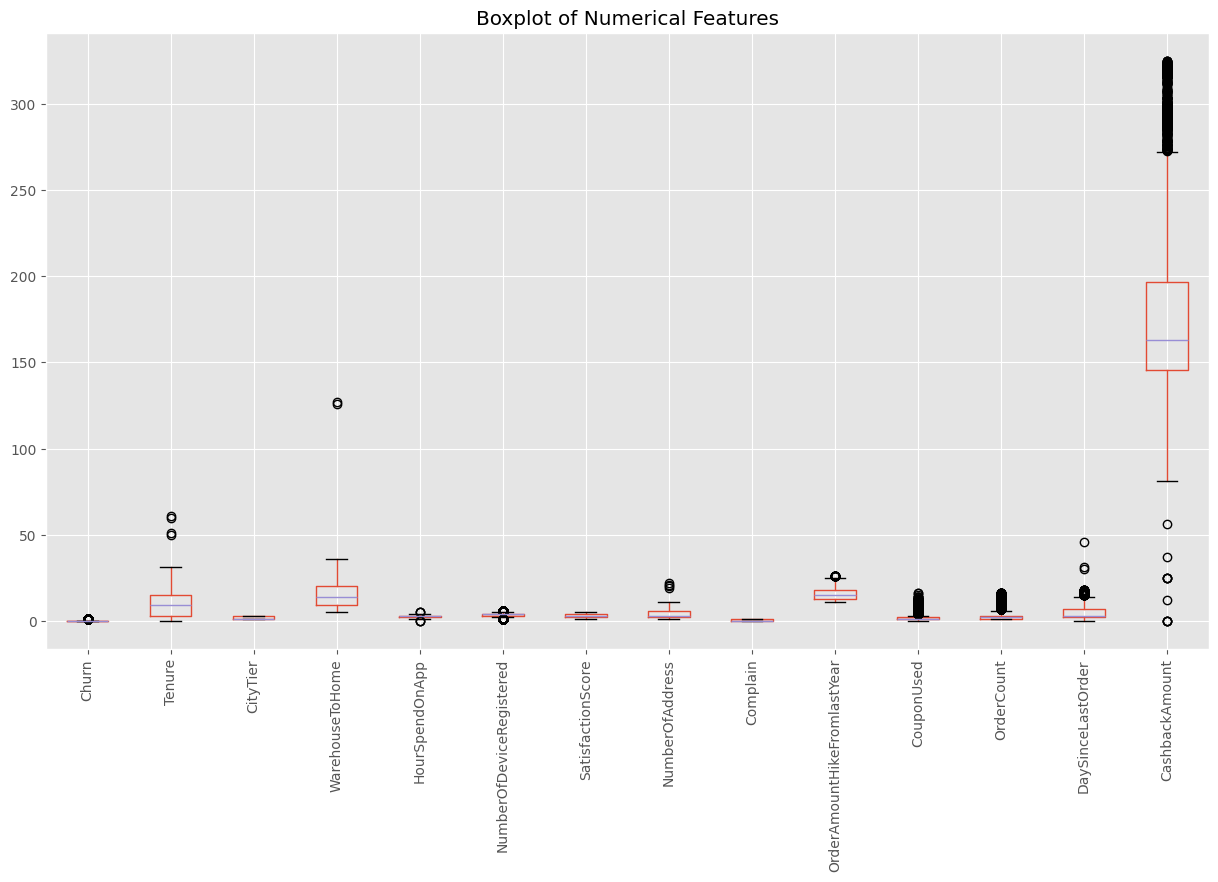

In [55]:
#Boxplot of Numerical Features

plt.figure(figsize=(15,8))

df_clean.select_dtypes(include="number").boxplot(rot=90)

plt.title("Boxplot of Numerical Features")

plt.show()

### Observation

Some numerical variables contain outliers. These values may represent genuine high-value customers and are retained.

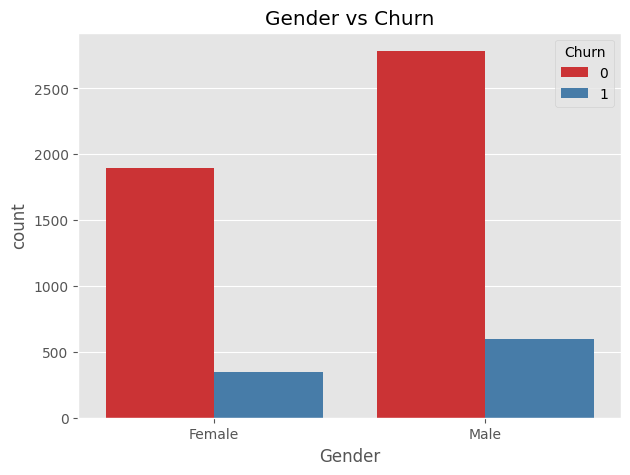

In [56]:
#Bivariate Analysis

#Gender vs Churn

plt.figure(figsize=(7,5))

sns.countplot(
    x="Gender",
    hue="Churn",
    data=df_clean,
    palette="Set1"
)

plt.title("Gender vs Churn")

plt.show()

### Observation

Male and female customers show similar churn behaviour with only slight differences.

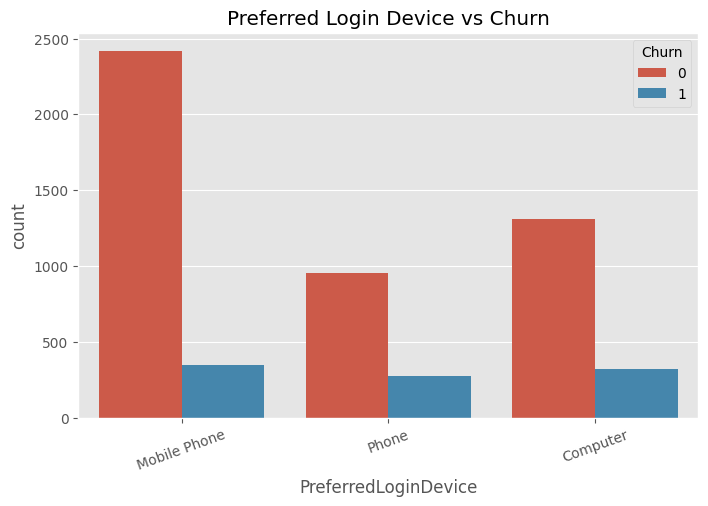

In [57]:
#Preferred Login Device vs Churn

plt.figure(figsize=(8,5))

sns.countplot(
    x="PreferredLoginDevice",
    hue="Churn",
    data=df_clean
)

plt.title("Preferred Login Device vs Churn")

plt.xticks(rotation=20)

plt.show()

### Observation

Customers using different login devices exhibit different churn patterns, indicating device preference may influence engagement.

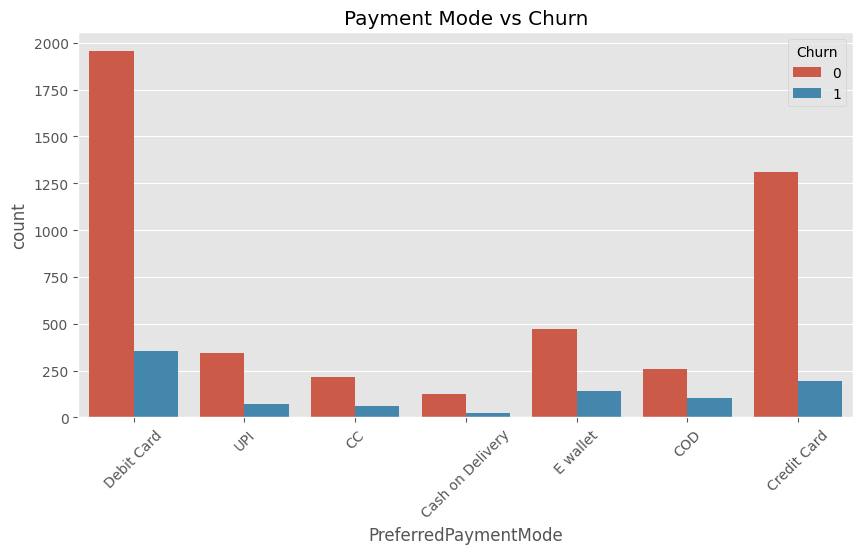

In [58]:
#Preferred Payment Mode vs Churn

plt.figure(figsize=(10,5))

sns.countplot(
    x="PreferredPaymentMode",
    hue="Churn",
    data=df_clean
)

plt.xticks(rotation=45)

plt.title("Payment Mode vs Churn")

plt.show()

### Observation

Some payment methods have noticeably higher churn percentages than others.

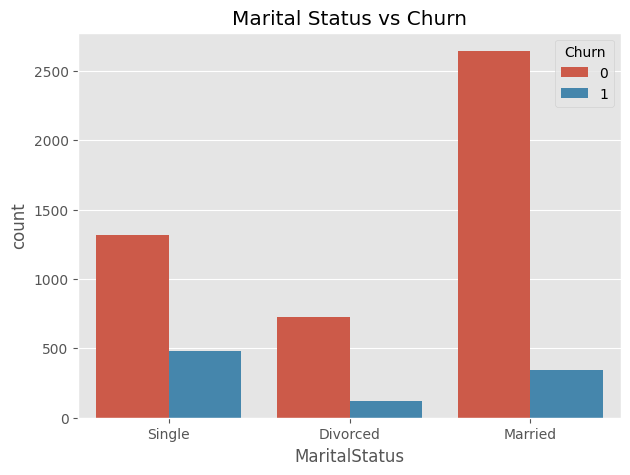

In [59]:
#Marital Status vs Churn

plt.figure(figsize=(7,5))

sns.countplot(
    x="MaritalStatus",
    hue="Churn",
    data=df_clean
)

plt.title("Marital Status vs Churn")

plt.show()

### Observation

Marital status appears to have some influence on churn, although the differences are moderate.

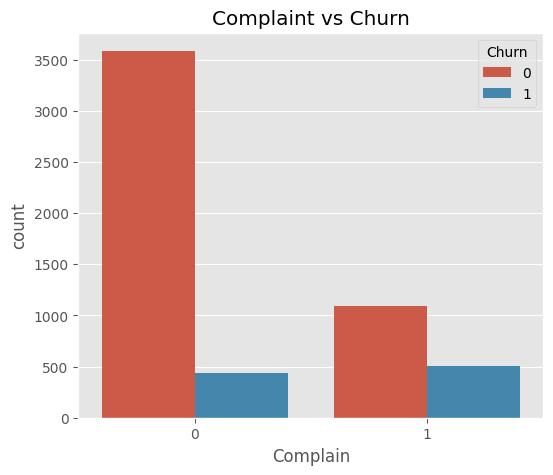

In [60]:
#Complaint vs Churn

plt.figure(figsize=(6,5))

sns.countplot(
    x="Complain",
    hue="Churn",
    data=df_clean
)

plt.title("Complaint vs Churn")

plt.show()

### Observation

Customers who have registered complaints are more likely to churn compared to those without complaints.

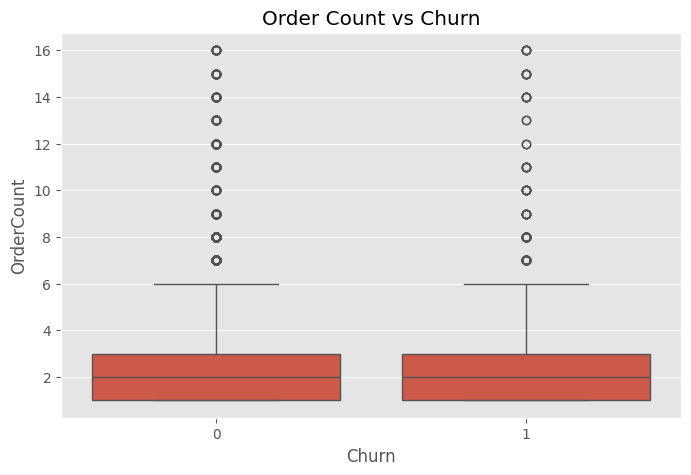

In [61]:
#Order Count vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="OrderCount",
    data=df_clean
)

plt.title("Order Count vs Churn")

plt.show()

### Observation

Customers with fewer orders tend to churn more frequently than customers with higher order counts.

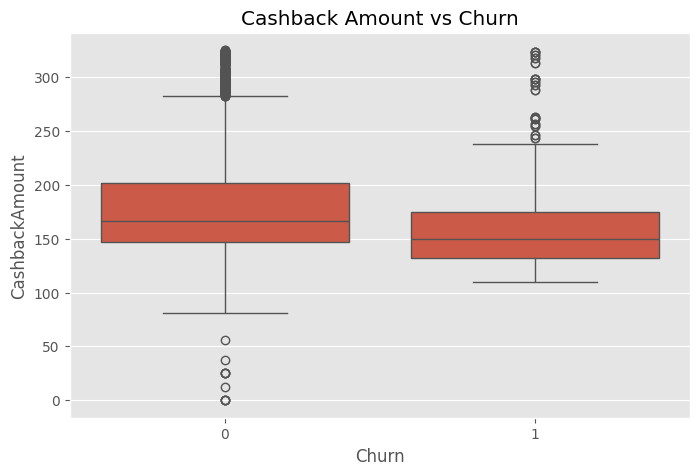

In [62]:
#Cashback Amount vs Churn

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="CashbackAmount",
    data=df_clean
)

plt.title("Cashback Amount vs Churn")

plt.show()

### Observation

Cashback benefits may influence customer retention, as retained customers often receive competitive cashback amounts.

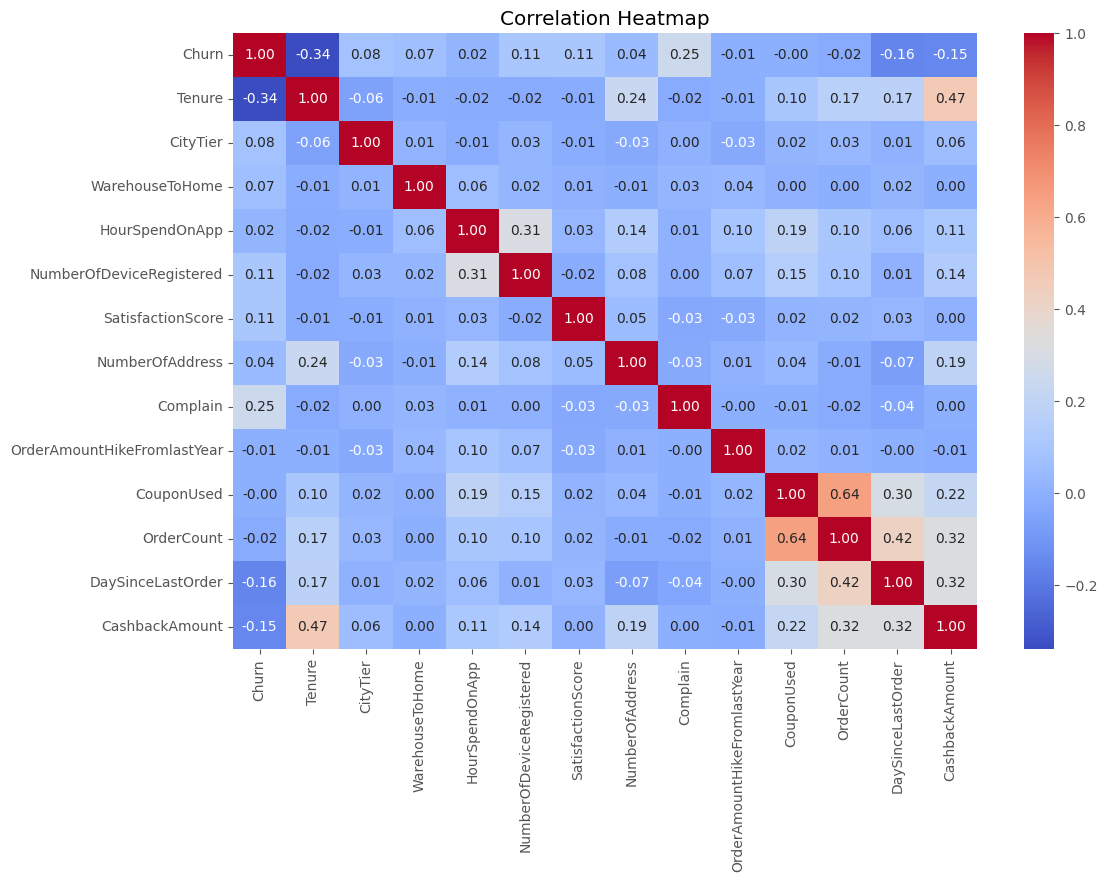

In [63]:
#Correlation Heatmap

plt.figure(figsize=(12,8))

corr = df_clean.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the strength of relationships among numerical variables. Features with stronger positive or negative correlations may significantly influence customer churn.

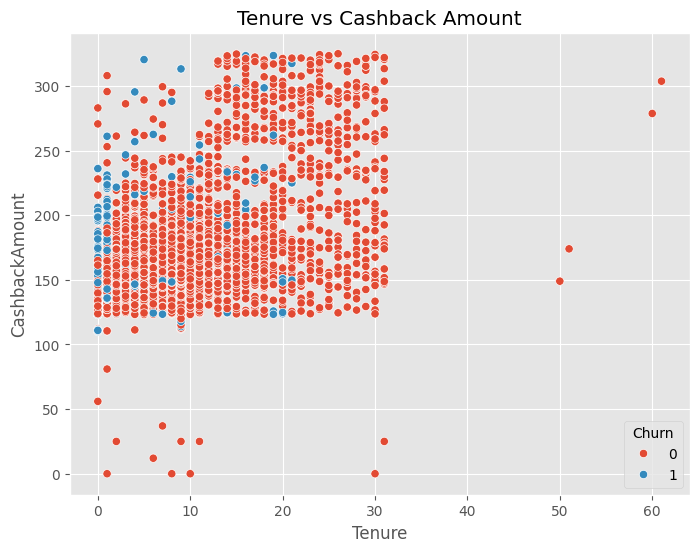

In [64]:
#Scatter Plot

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Tenure",
    y="CashbackAmount",
    hue="Churn",
    data=df_clean
)

plt.title("Tenure vs Cashback Amount")

plt.show()

### Observation

Customers with longer tenure generally demonstrate better retention, while cashback also appears to contribute to customer loyalty.

# Exploratory Data Analysis Summary

The exploratory data analysis revealed several important customer churn patterns:

- Customers who filed complaints are more likely to churn.
- Lower order counts are associated with higher churn.
- Cashback incentives appear to improve customer retention.
- Customer tenure influences churn behavior, with long-term customers showing better retention.
- Satisfaction score has a noticeable impact on churn.
- Payment method and login device also contribute to churn differences.

These findings will be summarized further in the final insights and business recommendations.

Final Insights, Business Recommendations & Conclusion

### Question 1

**What percentage of customers churned?**

The output above shows the percentage of customers who churned and those who were retained. This provides an overview of the customer retention rate.

In [65]:
# Calculate churn percentage

churn_percentage = (df_clean["Churn"].value_counts(normalize=True) * 100).round(2)

print(churn_percentage)

Churn
0    83.16
1    16.84
Name: proportion, dtype: float64


### Question 2

**Which customer group has the highest churn?**

Compare the churn percentages across customer groups. The category with the highest churn percentage represents the highest-risk customer segment.

In [66]:
# Churn by preferred order category

churn_category = pd.crosstab(
    df_clean["PreferedOrderCat"],
    df_clean["Churn"],
    normalize="index"
) * 100

churn_category.round(2)

Churn,0,1
PreferedOrderCat,,
Fashion,84.50,15.50
Grocery,95.12,4.88
Laptop & Accessory,89.76,10.24
Mobile,72.81,27.19
Mobile Phone,72.46,27.54
Others,92.42,7.58


### Question 3

**Which numerical features seem related to churn?**

Compare the average values between churned and retained customers. Features with noticeable differences are likely to influence churn.

In [67]:
# Average values grouped by churn

numerical_analysis = df_clean.groupby("Churn")[
    [
        "Tenure",
        "CashbackAmount",
        "OrderCount",
        "SatisfactionScore",
        "DaySinceLastOrder"
    ]
].mean()

numerical_analysis.round(2)

,Tenure,CashbackAmount,OrderCount,SatisfactionScore,DaySinceLastOrder
Churn,,,,,
0,11.40,180.64,2.99,3.00,4.71
1,3.86,160.37,2.81,3.39,3.22


### Question 4

**Which categorical features seem related to churn?**

Complaint status, payment method, and preferred order category show noticeable differences in churn behaviour.

In [68]:
categorical_features = [
    "Gender",
    "PreferredPaymentMode",
    "PreferredLoginDevice",
    "MaritalStatus",
    "Complain"
]

for feature in categorical_features:

    print("="*60)
    print(feature)

    print(pd.crosstab(
        df_clean[feature],
        df_clean["Churn"],
        normalize="index"
    ).round(2))

Gender
Churn      0     1
Gender            
Female  0.85  0.15
Male    0.82  0.18
PreferredPaymentMode
Churn                    0     1
PreferredPaymentMode            
CC                    0.78  0.22
COD                   0.71  0.29
Cash on Delivery      0.85  0.15
Credit Card           0.87  0.13
Debit Card            0.85  0.15
E wallet              0.77  0.23
UPI                   0.83  0.17
PreferredLoginDevice
Churn                    0     1
PreferredLoginDevice            
Computer              0.80  0.20
Mobile Phone          0.87  0.13
Phone                 0.78  0.22
MaritalStatus
Churn             0     1
MaritalStatus            
Divorced       0.85  0.15
Married        0.88  0.12
Single         0.73  0.27
Complain
Churn        0     1
Complain            
0         0.89  0.11
1         0.68  0.32


### Question 5

All missing values were successfully handled during the data cleaning stage. The cleaned dataset contains no missing values.

In [69]:
df_clean.isnull().sum()

Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

### Question 6

Some numerical columns contain outliers. These values were retained because they likely represent genuine customer behaviour rather than data entry errors.

In [70]:
outlier_df

,Column,Number of Outliers
0,Churn,948
1,Tenure,4
2,CityTier,0
3,WarehouseToHome,2
4,HourSpendOnApp,6
5,NumberOfDeviceRegistered,397
6,SatisfactionScore,0
7,NumberOfAddress,4
8,Complain,0
9,OrderAmountHikeFromlastYear,33


# Top 3 Factors Affecting Customer Churn

Based on the exploratory data analysis, the following factors have the greatest influence on customer churn:

### 1. Customer Complaints

Customers who submitted complaints were much more likely to churn.

---

### 2. Customer Tenure

Customers with shorter tenure had a higher churn rate.

---

### 3. Order Frequency

Customers with fewer orders were more likely to leave the platform.

These factors should be prioritised when designing customer retention strategies.

# Business Recommendations

Based on the analysis, the following strategies are recommended:

### Improve Customer Support

Respond quickly to customer complaints to reduce dissatisfaction.

---

### Reward Loyal Customers

Offer loyalty rewards and exclusive discounts to customers with longer tenure.

---

### Increase Customer Engagement

Provide personalised recommendations and promotional offers.

---

### Encourage Repeat Purchases

Introduce cashback offers and coupon campaigns to increase order frequency.

---

### Improve Customer Satisfaction

Regularly collect customer feedback and improve service quality.

---

### Monitor High-Risk Customers

Identify customers with low order counts and short tenure for targeted retention campaigns.

# Key Findings

- Most customers remain with the company, while a smaller percentage churn.
- Customer complaints are strongly associated with churn.
- Customers with shorter tenure are more likely to churn.
- Cashback incentives contribute positively to customer retention.
- Lower order counts are associated with higher churn.
- Satisfaction scores influence customer retention.
- Payment methods and login devices show moderate effects on churn.

# Conclusion

This exploratory data analysis successfully examined customer churn behaviour using the E-Commerce Customer Churn Dataset.

The dataset was cleaned by handling missing values, removing duplicate records, trimming inconsistent categorical values, and eliminating unnecessary identifier columns.

Through statistical analysis and visualisations, several important churn patterns were identified. Customer complaints, shorter tenure, and lower order frequency were found to be major contributors to customer churn.

These insights can help businesses improve customer satisfaction, increase retention, and reduce churn through targeted loyalty programmes and better customer support.

Overall, the project demonstrates how Exploratory Data Analysis can provide valuable business insights for improving customer retention.

In [71]:
# Save cleaned dataset

df_clean.to_csv(
    "../cleaned_data/Cleaned_Customer_Churn_Dataset_SasiRekha.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [72]:
plt.savefig("../images/churn_count.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>